In [34]:
# Librerias
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, metrics
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [2]:
# Directorios
train_dir = "../data/lesions/train"
test_dir = "../data/lesions/test" 

In [3]:
SEED = 42
tf.random.set_seed(SEED)

In [12]:
color_train = "#5FAA3F"  # azul
color_val = "#984bb7" 

# Importar y Redimensionar Máscaras

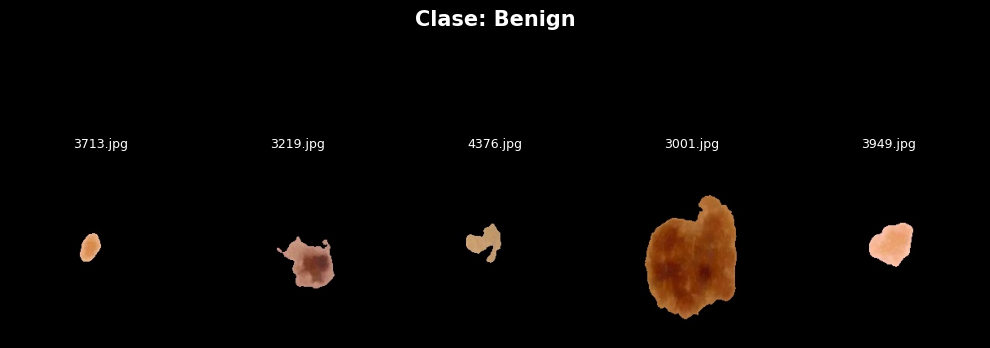

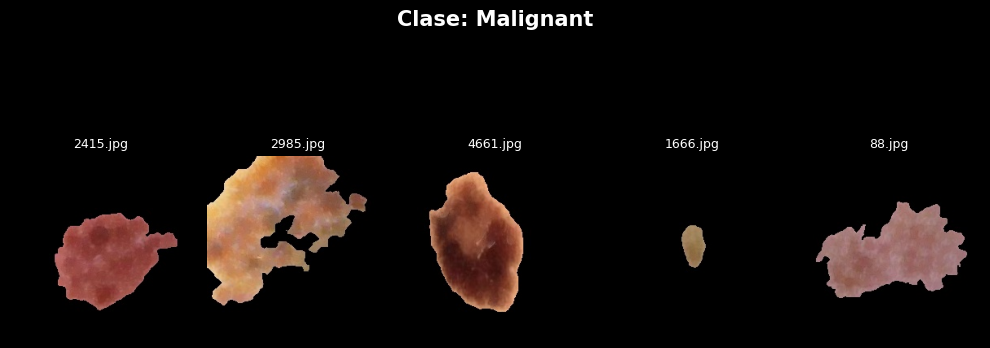

In [4]:
def mostrar_imagenes_random(carpeta, clase=None, n=5):
    if clase:
        carpeta = os.path.join(carpeta, clase)

    archivos = random.sample(os.listdir(carpeta), n)

    fig, axes = plt.subplots(1, n, figsize=(10, 4), facecolor='black')
    fig.suptitle(f"Clase: {clase}", fontsize=15, fontweight='bold', y=1.05, color='white')

    for ax, img_name in zip(axes, archivos):
        img = cv2.imread(os.path.join(carpeta, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(img_name, fontsize=9, color='white')
        ax.axis('off')
        ax.set_facecolor('black')  # fondo negro también para los ejes

    plt.subplots_adjust(top=0.8, wspace=0.05)  # red
    plt.tight_layout()
    plt.show()


# Ejemplo de uso
mostrar_imagenes_random(train_dir, "Benign", 5)
mostrar_imagenes_random(train_dir, "Malignant", 5)

### Normalización y Reescalado 

In [5]:
ROWS, COLS = 224, 224
BATCH= 32

In [6]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [7]:
train_gen = train_datagen.flow_from_directory(
    directory=train_dir,
    class_mode='categorical',      # 2 clases: Benign / Malignant
    batch_size=BATCH,
    target_size=(ROWS, COLS),
    color_mode='rgb',
    shuffle=True,
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    directory=test_dir,
    class_mode='categorical',
    batch_size=BATCH,
    target_size=(ROWS, COLS),
    color_mode='rgb',
    shuffle=False,
    seed=SEED
)

Found 11879 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


# Modelo

In [8]:
modelo1 = models.Sequential([
    # Bloque 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Bloque 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Bloque 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Clasificación
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(2, activation='softmax')
])

/Users/martinagarciagonzalez/Library/Python/3.12/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-15 03:32:18.265790: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-10-15 03:32:18.265829: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-10-15 03:32:18.265837: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-10-15 03:32:18.266018: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-15 03:32:18.266030: I tensorflow/core/common_runtime/pluggable_device/pluggabl

In [9]:
modelo1.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall')
    ]
)

In [10]:
history_1= modelo1.fit(
    train_gen,
    validation_data=test_gen,   # usas test como validación
    epochs=30,
)

Epoch 1/30


/Users/martinagarciagonzalez/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-10-15 03:32:19.235930: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


372/372 ━━━━━━━━━━━━━━━━━━━━ 170s 450ms/step - accuracy: 0.7199 - loss: 0.8782 - precision: 0.7199 - recall: 0.7199 - val_accuracy: 0.5170 - val_loss: 0.9933 - val_precision: 0.5170 - val_recall: 0.5170
Epoch 2/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 193s 518ms/step - accuracy: 0.7791 - loss: 0.5756 - precision: 0.7791 - recall: 0.7791 - val_accuracy: 0.7970 - val_loss: 0.4780 - val_precision: 0.7970 - val_recall: 0.7970
Epoch 3/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 182s 490ms/step - accuracy: 0.7725 - loss: 0.5793 - precision: 0.7725 - recall: 0.7725 - val_accuracy: 0.7985 - val_loss: 0.4675 - val_precision: 0.7985 - val_recall: 0.7985
Epoch 4/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 169s 455ms/step - accuracy: 0.7972 - loss: 0.5367 - precision: 0.7972 - recall: 0.7972 - val_accuracy: 0.8330 - val_loss: 0.4775 - val_precision: 0.8330 - val_recall: 0.8330
Epoch 5/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 180s 485ms/step - accuracy: 0.7972 - loss: 0.5250 - precision: 0.7972 - recall: 0.7972 - val_accuracy: 0.8315 - val

# Evaluación Modelo

## Curvas Train Vs Val

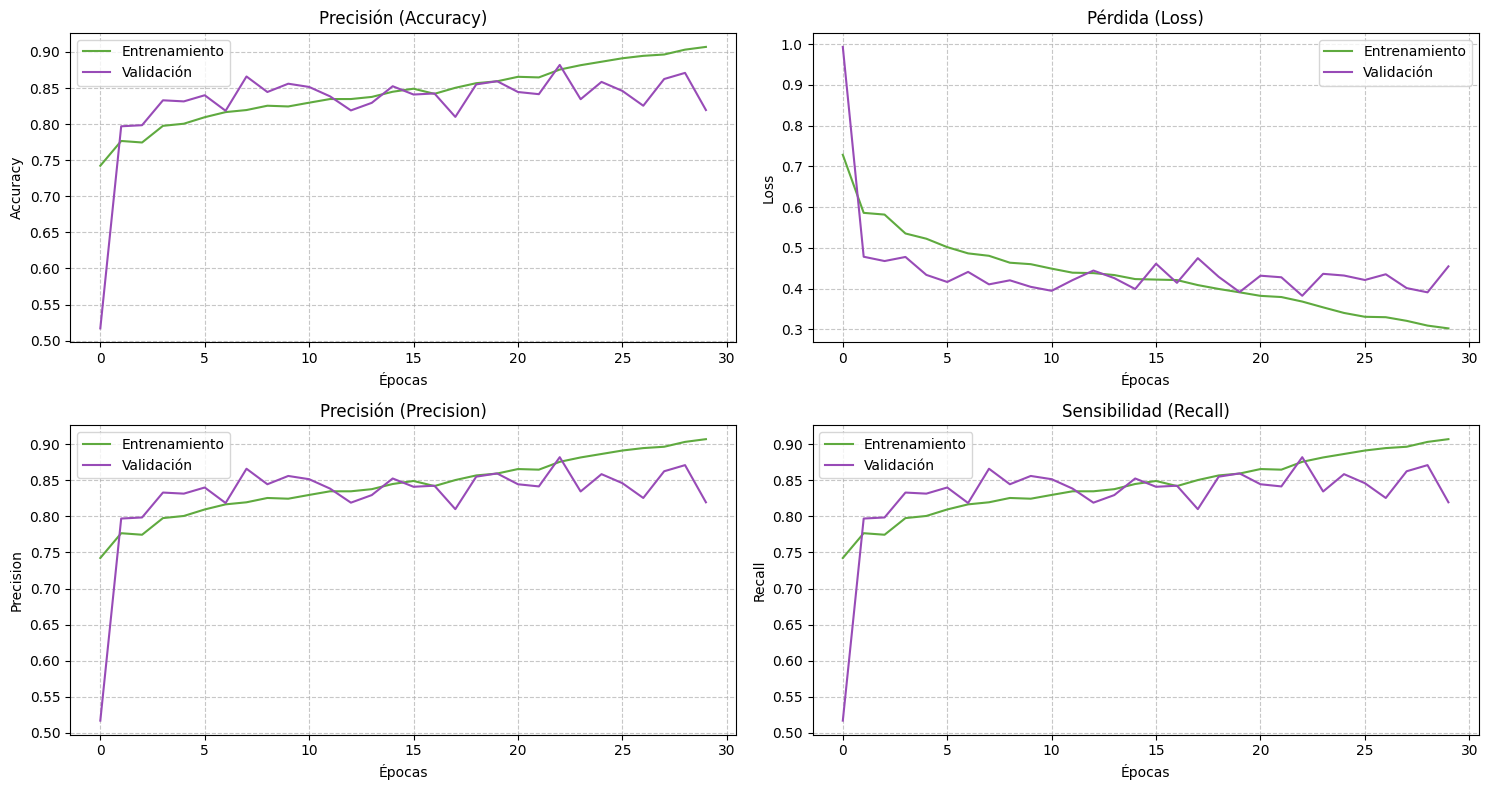

In [16]:
plt.figure(figsize=(15, 8))

# Accuracy
plt.subplot(2, 2, 1)
plt.plot(history_1.history['accuracy'], color=color_train, label='Entrenamiento')
plt.plot(history_1.history['val_accuracy'], color=color_val, label='Validación')
plt.title('Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Loss
plt.subplot(2, 2, 2)
plt.plot(history_1.history['loss'], color=color_train, label='Entrenamiento')
plt.plot(history_1.history['val_loss'], color=color_val, label='Validación')
plt.title('Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Precision (si definiste precision en metrics del modelo)
plt.subplot(2, 2, 3)
plt.plot(history_1.history['precision'], color=color_train, label='Entrenamiento')
plt.plot(history_1.history['val_precision'], color=color_val, label='Validación')
plt.title('Precisión (Precision)')
plt.xlabel('Épocas')
plt.ylabel('Precision')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Recall (si definiste recall en metrics del modelo)
plt.subplot(2, 2, 4)
plt.plot(history_1.history['recall'], color=color_train, label='Entrenamiento')
plt.plot(history_1.history['val_recall'], color=color_val, label='Validación')
plt.title('Sensibilidad (Recall)')
plt.xlabel('Épocas')
plt.ylabel('Recall')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Matriz de Confusión

In [24]:
y_pred_prob = modelo1.predict(test_gen)
y_true = test_gen.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step


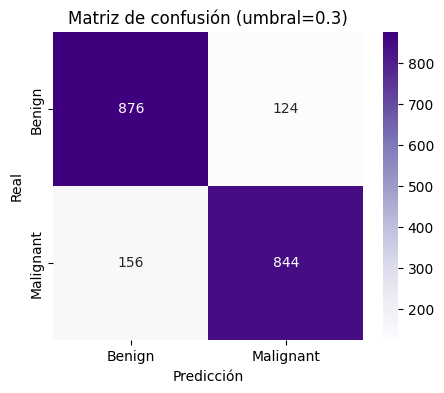

In [42]:
umbral = 0.3
y_pred_class = (y_pred_prob[:, 1] >= umbral).astype(int)

cm = confusion_matrix(y_true, y_pred_class)

labels = list(test_gen.class_indices.keys())
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f"Matriz de confusión (umbral={umbral})")
plt.show()

In [43]:
labels = list(test_gen.class_indices.keys())
print("Orden de clases:", test_gen.class_indices)

# Generar el reporte automático
print(classification_report(y_true, y_pred_class, target_names=labels, digits=3))

Orden de clases: {'Benign': 0, 'Malignant': 1}
              precision    recall  f1-score   support

      Benign      0.849     0.876     0.862      1000
   Malignant      0.872     0.844     0.858      1000

    accuracy                          0.860      2000
   macro avg      0.860     0.860     0.860      2000
weighted avg      0.860     0.860     0.860      2000



## Imágenes Externas

In [44]:
external_dir = "../data/lesions/external"
ROWS, COLS = 224, 224
BATCH = 1  # una imagen por lote para visualizar fácilmente

ext_datagen = ImageDataGenerator(rescale=1./255)

ext_gen = ext_datagen.flow_from_directory(
    directory=external_dir,
    target_size=(ROWS, COLS),
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False
)

Found 30 images belonging to 2 classes.


In [ ]:
# Probabilidades y clases
pred_probs = modelo1.predict(ext_gen)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = ext_gen.classes
labels = list(ext_gen.class_indices.keys())

/Users/martinagarciagonzalez/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


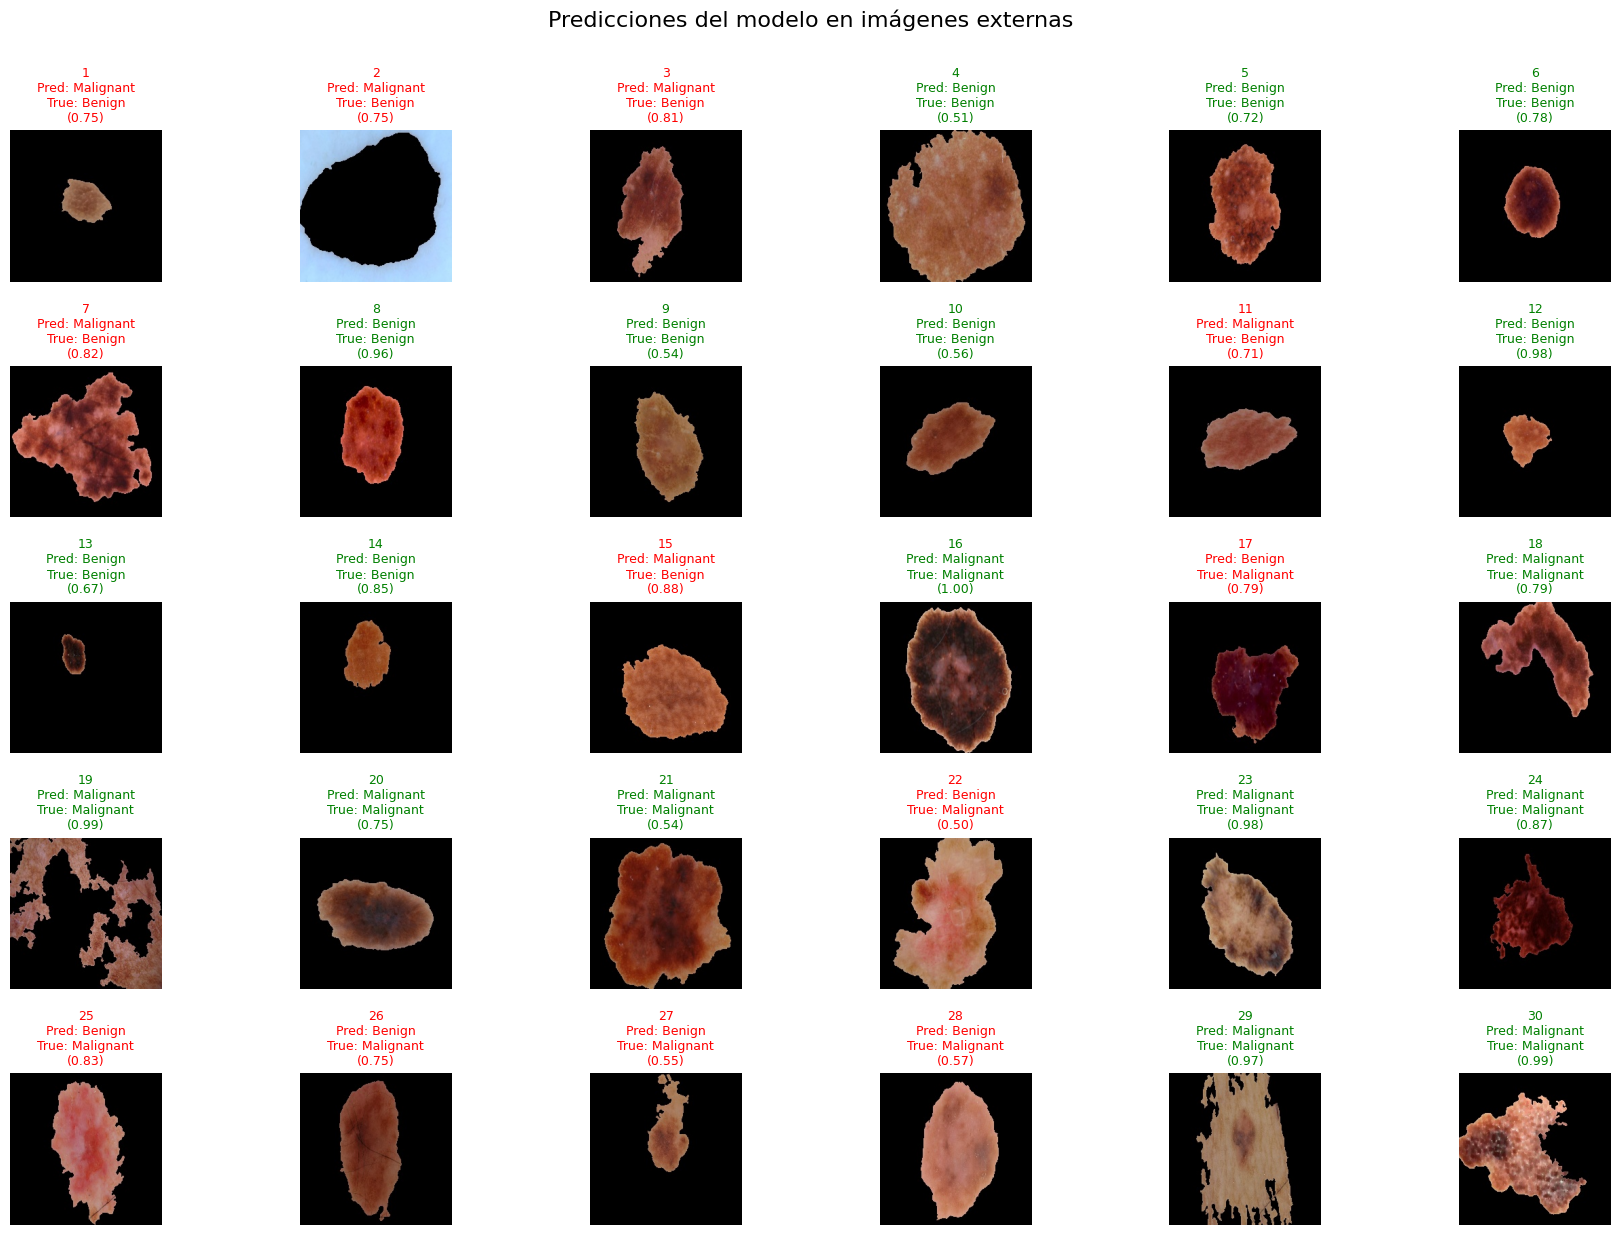

In [48]:
N = 30  # o len(ext_gen.filenames) si quieres todas
rows, cols = 5, 6

plt.figure(figsize=(18, 12))

for i in range(N):
    img, _ = ext_gen[i]
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img[0])

    true_label = labels[true_classes[i]]
    pred_label = labels[pred_classes[i]]
    prob = pred_probs[i][pred_classes[i]]

    color = "green" if true_label == pred_label else "red"
    plt.title(f"{i+1}\nPred: {pred_label}\nTrue: {true_label}\n({prob:.2f})", color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout(pad=1.5)
plt.suptitle("Predicciones del modelo en imágenes externas", fontsize=16, y=1.03)
plt.show()

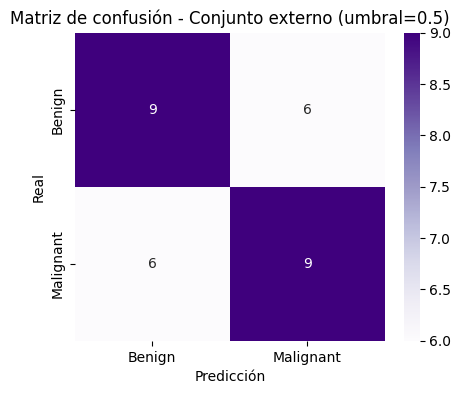

In [58]:
umbral = 0.5
y_pred_ext = (pred_probs[:, 1] >= umbral).astype(int)
y_true_ext = true_classes

# Calcular matriz de confusión
cm_ext = confusion_matrix(y_true_ext, y_pred_ext)

# Mostrar con seaborn
plt.figure(figsize=(5,4))
sns.heatmap(cm_ext, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de confusión - Conjunto externo (umbral={umbral})")
plt.show()

In [69]:
x = tf.keras.Input(shape=(224, 224, 3))
_ = modelo1(x)

In [70]:
grad_model = tf.keras.models.Model(
    [modelo1.input],
    [modelo1.get_layer("conv2d_2").output, modelo1.output]
)